In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [7]:
csv_path = "Names_hints/dpt2020.csv"
df = (
    pd.read_csv(csv_path, sep=";")
      .query("preusuel != '_PRENOMS_RARES'")
      .astype({"dpt": str})
)

df = df[df["annais"] != "XXXX"]

df.head()

,sexe,preusuel,annais,dpt,nombre
10885,1,AADIL,1983,84,3
10886,1,AADIL,1992,92,3
10888,1,AAHIL,2016,95,3
10892,1,AARON,1962,75,3
10893,1,AARON,1976,75,3


In [8]:
df["sexe"].value_counts()

sexe
2    1966210
1    1702064
Name: count, dtype: int64

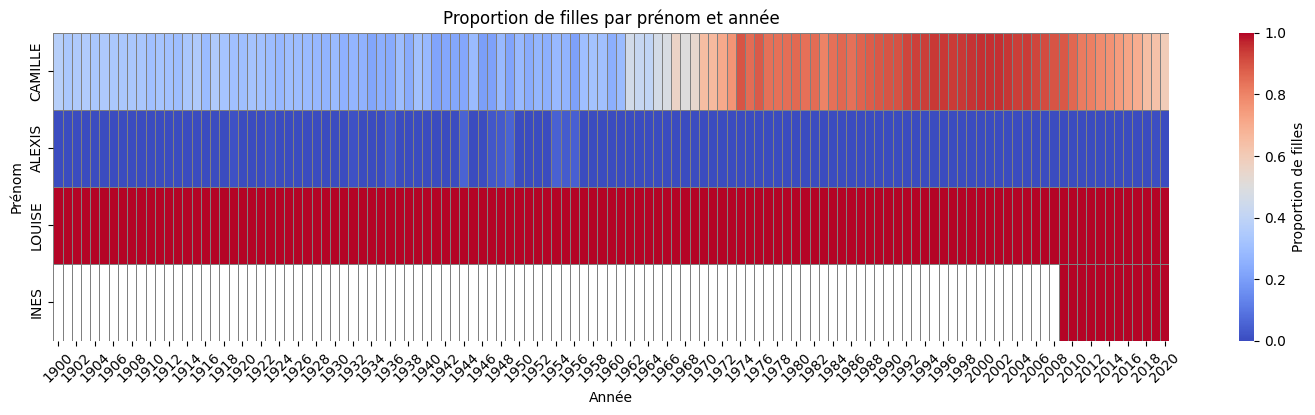

In [9]:
import seaborn as sns

prenoms = ["CAMILLE", "ALEXIS", "LOUISE", "INES"]
colors = plt.cm.tab10.colors

prenoms_selectionnes = prenoms
df_heatmap = df[df["preusuel"].isin(prenoms_selectionnes)]

pivot = df_heatmap.pivot_table(
    index="preusuel",
    columns=["annais", "sexe"],
    values="nombre",
    aggfunc="sum",
    fill_value=0
)

years = sorted(df_heatmap["annais"].unique())
heatmap_data = []
for prenom in prenoms_selectionnes:
    row = []
    for year in years:
        nb_garcons = pivot.get((year, 1), pd.Series()).get(prenom, 0)
        nb_filles = pivot.get((year, 2), pd.Series()).get(prenom, 0)
        total = nb_garcons + nb_filles
        prop_filles = nb_filles / total if total > 0 else None
        row.append(prop_filles)
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data, index=prenoms_selectionnes, columns=years)

plt.figure(figsize=(18, 4))
sns.heatmap(
    heatmap_df,
    cmap="coolwarm",
    cbar_kws={'label': 'Proportion de filles'},
    linewidths=0.5,
    linecolor='gray',
    vmin=0, vmax=1
)
plt.title("Proportion de filles par prénom et année")
plt.xlabel("Année")
plt.ylabel("Prénom")
plt.xticks(rotation=45)

plt.savefig("charts/GenderChart.svg", format="svg", bbox_inches="tight")

plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import seaborn as sns

annee_min, annee_max = int(years[0]), int(years[-1])
slider = widgets.IntRangeSlider(
    value=[annee_min, annee_max],
    min=annee_min,
    max=annee_max,
    step=1,
    description='Années',
    continuous_update=False,
    layout=widgets.Layout(width='80%')
)

name_input = widgets.Text(
    value='CAMILLE',
    placeholder='Séparer les prénoms par des virgules',
    description='Prénoms',
    layout=widgets.Layout(width='80%')
)

output = widgets.Output()

def update_plot(_=None):
    with output:
        clear_output(wait=True)
        debut, fin = map(str, slider.value)
        selected_cols = [col for col in heatmap_df.columns if debut <= col <= fin]

        # Extraire les prénoms
        names = [name.strip().upper() for name in name_input.value.split(",") if name.strip()]
        filtered_df = heatmap_df.loc[heatmap_df.index.isin(names), selected_cols]

        if filtered_df.empty:
            print("Aucun prénom valide trouvé.")
            return

        plt.figure(figsize=(max(8, len(selected_cols) // 2), 4))
        sns.heatmap(
            filtered_df,
            cmap="coolwarm",
            cbar_kws={'label': 'Proportion de filles'},
            linewidths=0.5,
            linecolor='gray',
            vmin=0, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 8}
        )
        plt.title(f"Proportion de filles par prénom ({debut}-{fin})")
        plt.xlabel("Année")
        plt.ylabel("Prénom")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

slider.observe(update_plot, names="value")
name_input.observe(update_plot, names="value")

display(name_input, slider, output)
update_plot()


Text(value='CAMILLE', description='Prénoms', layout=Layout(width='80%'), placeholder='Séparer les prénoms par …

IntRangeSlider(value=(1900, 2020), continuous_update=False, description='Années', layout=Layout(width='80%'), …

Output()